# 03 — stage 2 (signals): the full trade mechanics on ONE clean pair

We take **one** pair that survived the train+OOS cointegration screen in nb02
(`GMTUSDT / KAVAUSDT`) and trade it on **2025** — a period we have *not touched*
(we selected on 2024). Goal here is NOT a portfolio number yet; it is to nail the
**mechanics of a single pairs trade** slowly and visibly, so we trust the PnL
engine before scaling to many pairs.

**The rule (rolling / adaptive — this directly fixes nb01's failure).**
nb01 showed a *fixed* long-run mean drifts away. So instead of a frozen mean we
use a **rolling causal window** `W`: at every bar, using only the *past* `W`
bars, we

1. estimate the hedge ratio **β** (OLS of log(GMT) on log(KAVA)),
2. build the spread `log(GMT) - β·log(KAVA)` and its rolling **mean** and **std**,
3. form the z-score `z = (spread - mean) / std`.

Everything at bar *t* uses data up to *t-1* → no lookahead.

**Trade logic (mean-reversion):**
- flat, `z ≥ +Z_ENTRY` → **SHORT the spread** (short GMT, long β·KAVA): we bet the
  stretched spread falls back.
- flat, `z ≤ -Z_ENTRY` → **LONG the spread** (long GMT, short β·KAVA).
- in a trade → **exit** when `|z| ≤ Z_EXIT` (reverted, take profit) **or**
  `|z| ≥ Z_STOP` (blown out, stop loss).
- **β is frozen at entry** (a trader sets the hedge ratio when opening); the
  signal z keeps using the rolling β. This tiny inconsistency is realistic and
  negligible over one trade.

**Costs (the make-or-break for pairs):** a pair trade touches **two legs**, and
we pay on the way in AND out. With `c` = cost per side per leg (in bps), one full
round trip costs `≈ 2·c·(1+β)` of gross notional. On mid-liquidity alts like
these, `c` is not tiny — we'll test 5 / 10 / 20 bps and watch the edge survive
or die.

In [1]:
import sys; sys.path.insert(0, ".")   # cwd = notebooks/pairs
from _lab import *
import numpy as np, pandas as pd

SYM_A, SYM_B = "GMTUSDT", "KAVAUSDT"
TF = "4h"
px = load_pair(SYM_A, SYM_B, "2025-01-01", "2026-01-01", tf=TF)   # untouched period
la, lb = np.log(px["a"]), np.log(px["b"])
print(f"{SYM_A}/{SYM_B}  {len(px)} bars 4h  {px.index[0]} -> {px.index[-1]}")

# ---- rolling causal beta / spread / z --------------------------------------
W = 270                     # ~45 days at 4h; trailing estimation window
def rolling_signal(la, lb, W):
    # rolling OLS beta of la on lb over trailing W bars (causal), then z of spread.
    # beta_t = Cov_W(la,lb)/Var_W(lb) using windows ending at t (shifted 1 for causality).
    lb_m = lb.rolling(W).mean(); la_m = la.rolling(W).mean()
    cov  = (la*lb).rolling(W).mean() - la_m*lb_m
    var  = (lb*lb).rolling(W).mean() - lb_m*lb_m
    beta = (cov/var).shift(1)                       # use window ending at t-1
    spread = la - beta*lb
    m  = spread.rolling(W).mean().shift(1)
    sd = spread.rolling(W).std().shift(1)
    z  = (spread - m)/sd
    return beta, spread, z
beta, spread, z = rolling_signal(la, lb, W)
print(f"beta range (rolling): {beta.min():.2f} .. {beta.max():.2f} "
      f"(median {beta.median():.2f})")
print(f"usable bars after warmup: {z.notna().sum()}")

GMTUSDT/KAVAUSDT  2190 bars 4h  2025-01-01 00:00:00+00:00 -> 2025-12-31 20:00:00+00:00
beta range (rolling): -0.00 .. 2.17 (median 0.89)
usable bars after warmup: 1650


In [2]:
# ---- the trade simulator ---------------------------------------------------
def backtest(la, lb, beta, z, Z_ENTRY=2.0, Z_EXIT=0.5, Z_STOP=3.5, cost_bps=10.0):
    ra = la.diff(); rb = lb.diff()                  # per-bar log returns of each leg
    c = cost_bps/1e4
    pos = 0; beta_e = np.nan; trades = []; pnl = pd.Series(0.0, index=la.index)
    entry_i = None; entry_t = None
    zz = z.values; idx = z.index
    for i in range(1, len(idx)):
        zt = zz[i]
        if pos == 0:
            if np.isfinite(zt) and zt >= Z_ENTRY:  pos, beta_e, entry_i, entry_t = -1, beta.iloc[i], i, idx[i]
            elif np.isfinite(zt) and zt <= -Z_ENTRY: pos, beta_e, entry_i, entry_t = +1, beta.iloc[i], i, idx[i]
            if pos != 0:
                pnl.iloc[i] -= c*(1+abs(beta_e))    # entry cost (both legs)
        else:
            # spread portfolio log-return this bar: long spread = +1*(ra - beta*rb)
            pnl.iloc[i] += pos*(ra.iloc[i] - beta_e*rb.iloc[i])
            hit_exit = abs(zt) <= Z_EXIT
            hit_stop = abs(zt) >= Z_STOP
            if hit_exit or hit_stop or i == len(idx)-1:
                pnl.iloc[i] -= c*(1+abs(beta_e))    # exit cost (both legs)
                seg = pnl.iloc[entry_i:i+1].sum()
                trades.append(dict(entry=entry_t, exit=idx[i], side=pos, bars=i-entry_i,
                                   z_in=zz[entry_i], z_out=zt, ret=seg,
                                   why="stop" if hit_stop else ("exit" if hit_exit else "eod")))
                pos = 0; beta_e = np.nan
    return pd.DataFrame(trades), pnl

def stats(tr, pnl, label):
    if len(tr)==0: print(f"{label}: no trades"); return
    r = tr.ret
    eq = (1+pnl.cumsum()) if False else pnl.cumsum()  # additive equity (log-ish)
    net = pnl.sum()
    mdd = (pnl.cumsum().cummax() - pnl.cumsum()).max()
    print(f"{label:16s} n={len(tr):3d}  net={net:+.3f}  "
          f"mean/trade={r.mean():+.4f}  median={r.median():+.4f}  "
          f"win={100*(r>0).mean():4.1f}%  m/std={r.mean()/r.std():+.3f}  "
          f"maxDD={mdd:.3f}  stops={100*(tr.why=='stop').mean():.0f}%")
    return net, mdd

tr, pnl = backtest(la, lb, beta, z, cost_bps=10.0)
print("GMT/KAVA 2025, rolling z (W=270), entry|z|>2 exit|z|<0.5 stop|z|>3.5, 10bps/side/leg:\n")
stats(tr, pnl, "strategy")
print("\nfirst / last few trades:")
print(tr.head(6).to_string(index=False))

GMT/KAVA 2025, rolling z (W=270), entry|z|>2 exit|z|<0.5 stop|z|>3.5, 10bps/side/leg:

strategy         n=  6  net=+0.081  mean/trade=+0.0136  median=-0.0823  win=33.3%  m/std=+0.046  maxDD=0.444  stops=0%

first / last few trades:
                    entry                      exit  side  bars      z_in     z_out       ret  why
2025-05-07 08:00:00+00:00 2025-05-25 08:00:00+00:00    -1   108  2.099208  0.455644 -0.148555 exit
2025-07-03 12:00:00+00:00 2025-07-29 20:00:00+00:00    -1   158  2.001652  0.461758 -0.156335 exit
2025-08-15 16:00:00+00:00 2025-08-27 08:00:00+00:00     1    70 -2.196930 -0.430010 -0.015976 exit
2025-09-14 12:00:00+00:00 2025-10-21 12:00:00+00:00     1   222 -2.051566 -0.498416  0.594870 exit
2025-11-02 12:00:00+00:00 2025-11-23 00:00:00+00:00     1   123 -2.157348 -0.457725 -0.199733 exit
2025-11-24 20:00:00+00:00 2025-12-16 00:00:00+00:00    -1   127  2.200893  0.492365  0.007067 exit


In [3]:
# ---- cost sensitivity: does the edge survive realistic 2-leg costs? --------
print("cost sensitivity (per side per leg):\n")
for cb in [0, 5, 10, 20, 30]:
    tr_c, pnl_c = backtest(la, lb, beta, z, cost_bps=cb)
    stats(tr_c, pnl_c, f"c={cb:>2}bps")

cost sensitivity (per side per leg):

c= 0bps          n=  6  net=+0.107  mean/trade=+0.0179  median=-0.0778  win=33.3%  m/std=+0.060  maxDD=0.429  stops=0%
c= 5bps          n=  6  net=+0.094  mean/trade=+0.0157  median=-0.0800  win=33.3%  m/std=+0.053  maxDD=0.436  stops=0%
c=10bps          n=  6  net=+0.081  mean/trade=+0.0136  median=-0.0823  win=33.3%  m/std=+0.046  maxDD=0.444  stops=0%
c=20bps          n=  6  net=+0.056  mean/trade=+0.0093  median=-0.0867  win=33.3%  m/std=+0.031  maxDD=0.461  stops=0%
c=30bps          n=  6  net=+0.030  mean/trade=+0.0050  median=-0.0912  win=33.3%  m/std=+0.017  maxDD=0.478  stops=0%


[saved] notebooks\pairs\_out\03_gmt_kava_2025.png


WindowsPath('C:/projects/researchlab/notebooks/pairs/_out/03_gmt_kava_2025.png')

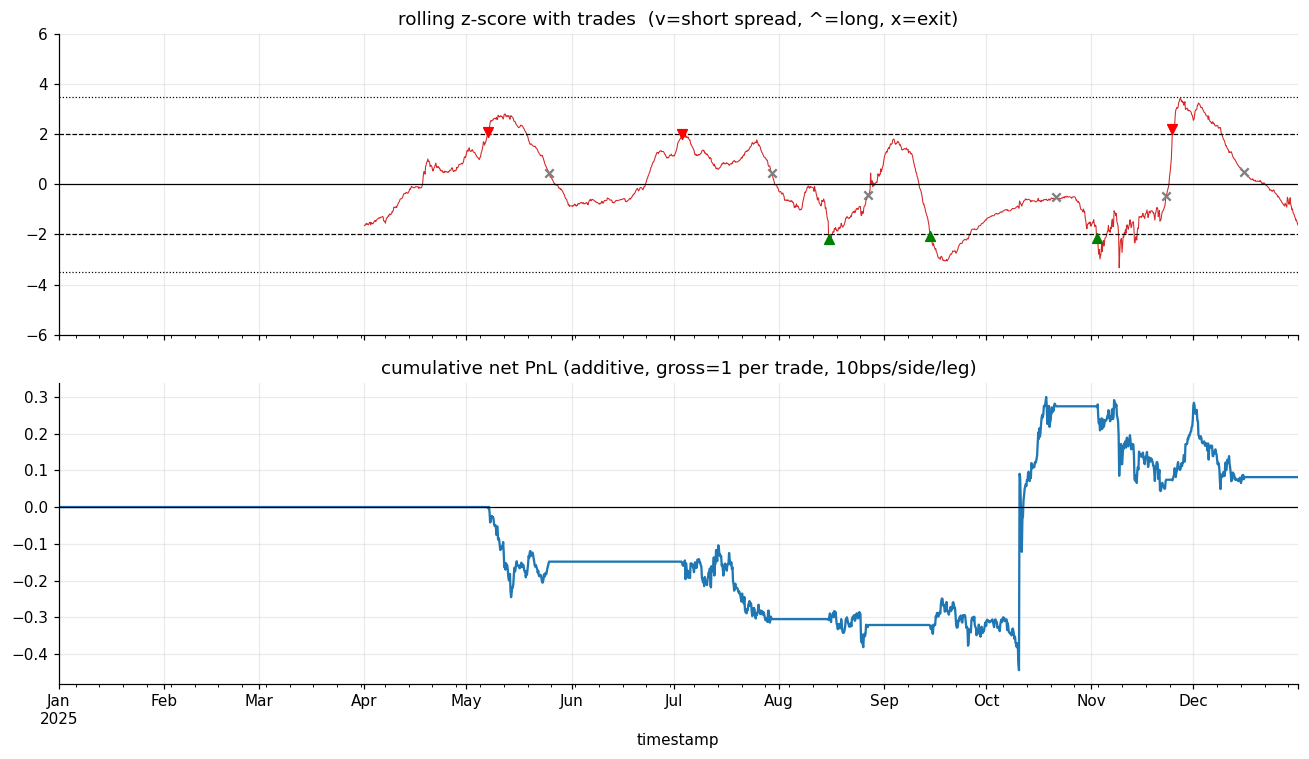

In [4]:
# ---- pictures: z with trade markers + equity curve -------------------------
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

z.plot(ax=ax[0], color="C3", lw=0.7)
for lvl, ls in [(0,"-"),(2,"--"),(-2,"--"),(3.5,":"),(-3.5,":")]:
    ax[0].axhline(lvl, color="k", lw=0.8, ls=ls)
for t in tr.itertuples():
    ax[0].scatter(t.entry, t.z_in, marker="v" if t.side<0 else "^",
                  color="red" if t.side<0 else "green", s=40, zorder=5)
    ax[0].scatter(t.exit, t.z_out, marker="x", color="gray", s=30, zorder=5)
ax[0].set_title("rolling z-score with trades  (v=short spread, ^=long, x=exit)")
ax[0].set_ylim(-6, 6)

pnl.cumsum().plot(ax=ax[1], color="C0")
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set_title("cumulative net PnL (additive, gross=1 per trade, 10bps/side/leg)")
show("03_gmt_kava_2025")

### How to read this
- **Top panel:** the rolling z. Red ▼ = we shorted the spread (z too high),
  green ▲ = we longed it (z too low), gray ✕ = exit (reverted to |z|<0.5 or
  stopped at |z|>3.5). Good behaviour = enter at the extremes, exit back near 0.
- **Bottom panel:** cumulative net PnL after 2-leg costs. Up-and-to-the-right =
  the timing edge beats the cost drag. Flat/down = costs (or decayed
  cointegration) eat it.
- **The decider is the cost-sensitivity table.** A stationary spread has ~zero
  drift, so the baseline for "no edge" is **net ≈ 0**. If the edge only exists at
  0 bps and dies by 10–20 bps, it is not tradeable on these mid-liquidity alts.
  `mean/std per trade` is the risk-adjusted read; `win%` alone is a trap.

This is one pair on one period — an anecdote, not proof. If the mechanics look
right and the edge survives costs, nb04 scales this to the survivor **portfolio**
(many pairs, capital cap, proper baseline).